In [4]:
!git clone -b second_branch https://github.com/ayeshathoi/CS682-Project.git
%cd CS682-Project

Cloning into 'CS682-Project'...
remote: Enumerating objects: 77, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 77 (delta 31), reused 30 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (77/77), 1.48 MiB | 4.68 MiB/s, done.
Resolving deltas: 100% (31/31), done.
/content/CS682-Project


In [5]:
!pip install -r requirements.txt

In [ ]:
import argparse

ap = argparse.ArgumentParser()

ROOT = Path("/content/CS682-Project")

this is correct code - interuppted

In [ ]:
#!/usr/bin/env python3
"""
Intra-task DNN steganography (Li et al., arXiv:2307.03444, Sec. 5.1):
  - Secret VGG11 trained on Fashion-MNIST (default split).
  - Stego model from secret + GFI + SIH, partial optimization on CIFAR-10 (D_st).
  - Metrics: ACC on both tasks; secret recoverability vs original checkpoint.
"""

from __future__ import annotations

import argparse
import copy
import random
import sys
from pathlib import Path

ROOT = Path("/content/CS682-Project")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from tqdm import tqdm

from core.extract import extract_secret_model, relative_param_error
from core.gfi import (
    apply_insertions,
    compute_position_importance,
    count_total_insertion_positions,
    top_n_insertion_positions,
)
from core.masks import apply_grad_mask_, build_partial_masks, channel_roles_after_sih, statistical_loss_conv
from core.sih import insert_side_filter_and_embed
from data import cifar10_loaders, evaluate, fashion_mnist_loaders
from models.vgg11 import VGG11


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def train_classifier(
    model: nn.Module,
    train_loader: torch.utils.data.DataLoader,
    device: torch.device,
    epochs: int,
    lr: float,
    desc: str,
) -> None:
    model.train()
    opt = Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    for ep in range(epochs):
        pbar = tqdm(train_loader, desc=f"{desc} ep{ep+1}/{epochs}", leave=False)
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = crit(logits, y)
            loss.backward()
            opt.step()


def train_stego_partial(
    stego: VGG11,
    grad_masks: dict,
    clean_ref: VGG11,
    train_loader: torch.utils.data.DataLoader,
    device: torch.device,
    epochs: int,
    lr: float,
    alpha: float,
    beta: float,
    desc: str,
) -> None:
    stego.train()
    clean_ref.eval()
    opt = Adam(stego.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    for ep in range(epochs):
        pbar = tqdm(train_loader, desc=f"{desc} ep{ep+1}/{epochs}", leave=False)
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(set_to_none=True)
            logits = stego(x)
            l_st = crit(logits, y)
            l_mu, l_sig = statistical_loss_conv(stego, clean_ref)
            loss = l_st + alpha * l_mu + beta * l_sig
            loss.backward()
            apply_grad_mask_(stego, grad_masks)
            opt.step()
import argparse

ap = argparse.ArgumentParser()

def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--data-dir", type=str, default=str('/content/drive/My Drive/CS682-Project/data'))
    ap.add_argument("--seed", type=int, default=0)
    ap.add_argument("--device", type=str, default="cuda" if torch.cuda.is_available() else "cpu")
    ap.add_argument("--batch-size", type=int, default=128)
    ap.add_argument("--epochs-secret", type=int, default=15)
    ap.add_argument("--epochs-clean", type=int, default=20)
    ap.add_argument("--epochs-stego", type=int, default=20)
    ap.add_argument("--lr", type=float, default=1e-3)
    ap.add_argument("--alpha", type=float, default=20.0)
    ap.add_argument("--beta", type=float, default=1.0)
    ap.add_argument("--gfi-fraction", type=float, default=0.30, help="top fraction of insertion positions (paper: 0.30)")
    ap.add_argument("--gfi-max-batches", type=int, default=0, help="0 = full CIFAR train for GFI gradients; else cap batches")
    ap.add_argument("--key", type=str, default="cs682-secret-key-phrase!!")
    args = ap.parse_args([]) # Modified line: Pass an empty list to parse_args()

    set_seed(args.seed)
    device = torch.device(args.device)

    fm_train, fm_test = fashion_mnist_loaders(args.data_dir, args.batch_size)
    cf_train, cf_test = cifar10_loaders(args.data_dir, args.batch_size)

    secret = VGG11().to(device)
    print("Training secret VGG11 on Fashion-MNIST...")
    train_classifier(secret, fm_train, device, args.epochs_secret, args.lr, "secret FMNIST")
    acc_secret_fm = evaluate(secret, fm_test, device)
    print(f"Secret model Fashion-MNIST test ACC: {100.0 * acc_secret_fm:.2f}%")

    secret.eval()
    gfi_batches = None if args.gfi_max_batches == 0 else args.gfi_max_batches
    print("Computing GFI importance on CIFAR-10 (D_st)...")
    imp = compute_position_importance(secret, cf_train, device, max_batches=gfi_batches)
    total_pos = count_total_insertion_positions(secret)
    n_sel = max(1, int(round(args.gfi_fraction * total_pos)))
    specs = top_n_insertion_positions(imp, n_sel)
    print(f"Insertion slots: {total_pos}, selecting top {n_sel} (~{100.0 * n_sel / total_pos:.1f}%).")

    rng = torch.Generator(device="cpu")
    rng.manual_seed(args.seed)
    stego_base, conv_masks = apply_insertions(secret, specs, rng)

    key = args.key.encode("utf-8")[:64]
    if len(key) < 8:
        key = key + b"\0" * (8 - len(key))

    stego_model, side_info = insert_side_filter_and_embed(stego_base, conv_masks, key, rng)
    stego_model = stego_model.to(device)

    gfi_shapes = {r: int(conv_masks[r].numel()) for r in sorted(conv_masks.keys())}
    roles = channel_roles_after_sih(conv_masks, side_info)
    grad_masks = build_partial_masks(stego_model, roles)

    clean = copy.deepcopy(stego_model)
    clean._initialize_weights()
    clean = clean.to(device)
    print("Training clean reference G_gamma on CIFAR-10 (full weights)...")
    train_classifier(clean, cf_train, device, args.epochs_clean, args.lr, "clean CIFAR")
    acc_clean = evaluate(clean, cf_test, device)
    print(f"Clean model CIFAR-10 test ACC: {100.0 * acc_clean:.2f}%")

    print("Training stego G_delta on CIFAR-10 (POS: interference only + stats losses)...")
    train_stego_partial(
        stego_model,
        grad_masks,
        clean,
        cf_train,
        device,
        args.epochs_stego,
        args.lr,
        args.alpha,
        args.beta,
        "stego CIFAR",
    )
    acc_stego = evaluate(stego_model, cf_test, device)
    print(f"Stego model CIFAR-10 test ACC: {100.0 * acc_stego:.2f}%")

    recovered = extract_secret_model(stego_model.cpu(), side_info, key, gfi_shapes).to(device)
    acc_rec_fm = evaluate(recovered, fm_test, device)
    print(f"Recovered secret Fashion-MNIST test ACC: {100.0 * acc_rec_fm:.2f}%")
    err = relative_param_error(secret.cpu(), recovered.cpu())
    print(f"Relative L1 param drift vs original secret: {err:.3e}")

    print("Done.")


if __name__ == "__main__":
    main()

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 215kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.97MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.74MB/s]
100%|██████████| 170M/170M [00:04<00:00, 39.6MB/s]


Training secret VGG11 on Fashion-MNIST...


KeyboardInterrupt: 

this includes print statements

In [ ]:
#!/usr/bin/env python3
"""
Intra-task DNN steganography (Li et al., arXiv:2307.03444, Sec. 5.1):
  - Secret VGG11 trained on Fashion-MNIST (default split).
  - Stego model from secret + GFI + SIH, partial optimization on CIFAR-10 (D_st).
  - Metrics: ACC on both tasks; secret recoverability vs original checkpoint.
  + Added logging of training dynamics (losses per epoch) for plotting.
"""

from __future__ import annotations

import argparse
import copy
import random
import sys
import csv
from pathlib import Path

ROOT = Path("/content/CS682-Project")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from tqdm import tqdm

from core.extract import extract_secret_model, relative_param_error
from core.gfi import (
    apply_insertions,
    compute_position_importance,
    count_total_insertion_positions,
    top_n_insertion_positions,
)
from core.masks import apply_grad_mask_, build_partial_masks, channel_roles_after_sih, statistical_loss_conv
from core.sih import insert_side_filter_and_embed
from data import cifar10_loaders, evaluate, fashion_mnist_loaders
from models.vgg11 import VGG11


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def train_classifier(
    model: nn.Module,
    train_loader: torch.utils.data.DataLoader,
    device: torch.device,
    epochs: int,
    lr: float,
    desc: str,
) -> list[float]:
    """
    Train a classifier and return per‑epoch average losses.
    """
    model.train()
    opt = Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    epoch_losses = []
    for ep in range(epochs):
        total_loss = 0.0
        num_batches = 0
        pbar = tqdm(train_loader, desc=f"{desc} ep{ep+1}/{epochs}", leave=False)
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = crit(logits, y)
            loss.backward()
            opt.step()
            total_loss += loss.item()
            num_batches += 1
            pbar.set_postfix(loss=loss.item())
        avg_loss = total_loss / num_batches
        epoch_losses.append(avg_loss)
        print(f"{desc} Epoch {ep+1}/{epochs} avg loss: {avg_loss:.4f}")
    return epoch_losses


def train_stego_partial(
    stego: VGG11,
    grad_masks: dict,
    clean_ref: VGG11,
    train_loader: torch.utils.data.DataLoader,
    device: torch.device,
    epochs: int,
    lr: float,
    alpha: float,
    beta: float,
    desc: str,
) -> dict:
    """
    Train stego model with partial gradient masking and statistical losses.
    Returns a dict with per‑epoch losses: total, l_st, l_mu, l_sig.
    """
    stego.train()
    clean_ref.eval()
    opt = Adam(stego.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    logs = {"epoch": [], "loss_total": [], "loss_st": [], "loss_mu": [], "loss_sig": []}
    for ep in range(epochs):
        total_loss = 0.0
        total_st = 0.0
        total_mu = 0.0
        total_sig = 0.0
        num_batches = 0
        pbar = tqdm(train_loader, desc=f"{desc} ep{ep+1}/{epochs}", leave=False)
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(set_to_none=True)
            logits = stego(x)
            l_st = crit(logits, y)
            l_mu, l_sig = statistical_loss_conv(stego, clean_ref)
            loss = l_st + alpha * l_mu + beta * l_sig
            loss.backward()
            apply_grad_mask_(stego, grad_masks)
            opt.step()

            total_loss += loss.item()
            total_st += l_st.item()
            total_mu += l_mu.item()
            total_sig += l_sig.item()
            num_batches += 1
            pbar.set_postfix(loss=loss.item(), l_st=l_st.item(), l_mu=l_mu.item(), l_sig=l_sig.item())

        avg_loss = total_loss / num_batches
        avg_st = total_st / num_batches
        avg_mu = total_mu / num_batches
        avg_sig = total_sig / num_batches
        logs["epoch"].append(ep+1)
        logs["loss_total"].append(avg_loss)
        logs["loss_st"].append(avg_st)
        logs["loss_mu"].append(avg_mu)
        logs["loss_sig"].append(avg_sig)
        print(f"{desc} Epoch {ep+1}/{epochs}: total={avg_loss:.4f}, l_st={avg_st:.4f}, l_mu={avg_mu:.4f}, l_sig={avg_sig:.4f}")
    return logs

def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--data-dir", type=str, default='/content/drive/My Drive/CS682-Project/data')
    parser.add_argument("--log-file", type=str, default=None, help="CSV file to save training dynamics (optional)")
    parser.add_argument("--seed", type=int, default=0)
    parser.add_argument("--device", type=str, default="cuda" if torch.cuda.is_available() else "cpu")
    parser.add_argument("--batch-size", type=int, default=128)
    parser.add_argument("--epochs-secret", type=int, default=15)
    parser.add_argument("--epochs-clean", type=int, default=20)
    parser.add_argument("--epochs-stego", type=int, default=20)
    parser.add_argument("--lr", type=float, default=1e-3)
    parser.add_argument("--alpha", type=float, default=20.0)
    parser.add_argument("--beta", type=float, default=1.0)
    parser.add_argument("--gfi-fraction", type=float, default=0.30)
    parser.add_argument("--gfi-max-batches", type=int, default=0)
    parser.add_argument("--key", type=str, default="cs682-secret-key-phrase!!")
    args, unknown = parser.parse_known_args()   # ← IGNORE unknown args
    if unknown:
        print(f"Warning: Ignoring unexpected arguments: {unknown}")


# def main() -> None:
#     parser = argparse.ArgumentParser()
#     parser.add_argument("--data-dir", type=str, default='/content/drive/My Drive/CS682-Project/data')
#     parser.add_argument("--log-file", type=str, default=None, help="CSV file to save training dynamics (optional)")
#     parser.add_argument("--seed", type=int, default=0)
#     parser.add_argument("--device", type=str, default="cuda" if torch.cuda.is_available() else "cpu")
#     parser.add_argument("--batch-size", type=int, default=128)
#     parser.add_argument("--epochs-secret", type=int, default=15)
#     parser.add_argument("--epochs-clean", type=int, default=20)
#     parser.add_argument("--epochs-stego", type=int, default=20)
#     parser.add_argument("--lr", type=float, default=1e-3)
#     parser.add_argument("--alpha", type=float, default=20.0)
#     parser.add_argument("--beta", type=float, default=1.0)
#     parser.add_argument("--gfi-fraction", type=float, default=0.30, help="top fraction of insertion positions (paper: 0.30)")
#     parser.add_argument("--gfi-max-batches", type=int, default=0, help="0 = full CIFAR train for GFI gradients; else cap batches")
#     parser.add_argument("--key", type=str, default="cs682-secret-key-phrase!!")
#     args = parser.parse_args()

    set_seed(args.seed)
    device = torch.device(args.device)

    fm_train, fm_test = fashion_mnist_loaders(args.data_dir, args.batch_size)
    cf_train, cf_test = cifar10_loaders(args.data_dir, args.batch_size)

    # -------- Secret model ----------
    secret = VGG11().to(device)
    print("Training secret VGG11 on Fashion-MNIST...")
    secret_losses = train_classifier(secret, fm_train, device, args.epochs_secret, args.lr, "secret FMNIST")
    acc_secret_fm = evaluate(secret, fm_test, device)
    print(f"Secret model Fashion-MNIST test ACC: {100.0 * acc_secret_fm:.2f}%")

    # -------- GFI importance ----------
    secret.eval()
    gfi_batches = None if args.gfi_max_batches == 0 else args.gfi_max_batches
    print("Computing GFI importance on CIFAR-10 (D_st)...")
    imp = compute_position_importance(secret, cf_train, device, max_batches=gfi_batches)
    total_pos = count_total_insertion_positions(secret)
    n_sel = max(1, int(round(args.gfi_fraction * total_pos)))
    specs = top_n_insertion_positions(imp, n_sel)
    print(f"Insertion slots: {total_pos}, selecting top {n_sel} (~{100.0 * n_sel / total_pos:.1f}%).")

    # -------- Insert side‑injected filters ----------
    rng = torch.Generator(device="cpu")
    rng.manual_seed(args.seed)
    stego_base, conv_masks = apply_insertions(secret, specs, rng)

    key = args.key.encode("utf-8")[:64]
    if len(key) < 8:
        key = key + b"\0" * (8 - len(key))

    stego_model, side_info = insert_side_filter_and_embed(stego_base, conv_masks, key, rng)
    stego_model = stego_model.to(device)

    gfi_shapes = {r: int(conv_masks[r].numel()) for r in sorted(conv_masks.keys())}
    roles = channel_roles_after_sih(conv_masks, side_info)
    grad_masks = build_partial_masks(stego_model, roles)

    # -------- Clean reference model (full training) ----------
    clean = copy.deepcopy(stego_model)
    clean._initialize_weights()
    clean = clean.to(device)
    print("Training clean reference G_gamma on CIFAR-10 (full weights)...")
    clean_losses = train_classifier(clean, cf_train, device, args.epochs_clean, args.lr, "clean CIFAR")
    acc_clean = evaluate(clean, cf_test, device)
    print(f"Clean model CIFAR-10 test ACC: {100.0 * acc_clean:.2f}%")

    # -------- Stego training (partial updates) ----------
    print("Training stego G_delta on CIFAR-10 (POS: interference only + stats losses)...")
    stego_logs = train_stego_partial(
        stego_model,
        grad_masks,
        clean,
        cf_train,
        device,
        args.epochs_stego,
        args.lr,
        args.alpha,
        args.beta,
        "stego CIFAR",
    )
    acc_stego = evaluate(stego_model, cf_test, device)
    print(f"Stego model CIFAR-10 test ACC: {100.0 * acc_stego:.2f}%")

    # -------- Secret recovery ----------
    recovered = extract_secret_model(stego_model.cpu(), side_info, key, gfi_shapes).to(device)
    acc_rec_fm = evaluate(recovered, fm_test, device)
    print(f"Recovered secret Fashion-MNIST test ACC: {100.0 * acc_rec_fm:.2f}%")
    err = relative_param_error(secret.cpu(), recovered.cpu())
    print(f"Relative L1 param drift vs original secret: {err:.3e}")

    # -------- Save training dynamics (optional) ----------
    if args.log_file:
        with open(args.log_file, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(["phase", "epoch", "loss_avg"])
            for ep, loss in enumerate(secret_losses, 1):
                writer.writerow(["secret_fmnist", ep, loss])
            for ep, loss in enumerate(clean_losses, 1):
                writer.writerow(["clean_cifar", ep, loss])
            # Stego logs have multiple columns
            writer.writerow(["stego_cifar_epoch", "loss_total", "loss_st", "loss_mu", "loss_sig"])
            for i in range(len(stego_logs["epoch"])):
                writer.writerow([
                    stego_logs["epoch"][i],
                    stego_logs["loss_total"][i],
                    stego_logs["loss_st"][i],
                    stego_logs["loss_mu"][i],
                    stego_logs["loss_sig"][i]
                ])
        print(f"Training dynamics saved to {args.log_file}")

    print("Done.")


if __name__ == "__main__":
    main()

Training secret VGG11 on Fashion-MNIST...


secret FMNIST Epoch 1/15 avg loss: 0.5415


secret FMNIST Epoch 2/15 avg loss: 0.2901


secret FMNIST Epoch 3/15 avg loss: 0.2398


secret FMNIST Epoch 4/15 avg loss: 0.2041


...

Clean model CIFAR-10 test ACC: 75.93%
Training stego G_delta on CIFAR-10 (POS: interference only + stats losses)...


stego CIFAR Epoch 1/20: total=2.2374, l_st=2.2311, l_mu=0.0003, l_sig=0.0012


stego CIFAR Epoch 2/20: total=1.5746, l_st=1.5712, l_mu=0.0002, l_sig=0.0003


stego CIFAR Epoch 3/20: total=1.2596, l_st=1.2573, l_mu=0.0001, l_sig=0.0001


KeyboardInterrupt: 

## if you want to re-run the codes from the start - run this cell first before runing any other cells

In [7]:
import shutil
shutil.rmtree("/content/drive/My Drive/CS682-Project/checkpoints", ignore_errors=True)
import os
os.remove("/content/drive/My Drive/CS682-Project/sweep_metrics.jsonl") if os.path.exists("/content/drive/My Drive/CS682-Project/sweep_metrics.jsonl") else None
print("Full reset done.")

Full reset done.


##Run from here -- optimized + generate plots ??

In [8]:
!git clone -b second_branch https://github.com/ayeshathoi/CS682-Project.git
%cd CS682-Project

Cloning into 'CS682-Project'...
remote: Enumerating objects: 77, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 77 (delta 31), reused 30 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (77/77), 1.48 MiB | 62.96 MiB/s, done.
Resolving deltas: 100% (31/31), done.
/content/CS682-Project/CS682-Project


In [9]:
!pip install -r requirements.txt

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
#!/usr/bin/env python3
"""
Intra-task DNN steganography (Li et al., arXiv:2307.03444, Sec. 5.1):
  - Secret VGG11 trained on Fashion-MNIST (default split).
  - Stego model from secret + GFI + SIH, partial optimization on CIFAR-10 (D_st).
  - Metrics: ACC on both tasks; secret recoverability vs original checkpoint.
  + Logging of training dynamics (losses per epoch) for plotting.
  + Checkpointing: each training phase is skipped if a matching checkpoint exists.
  + Local data caching: copies dataset from Drive to /content/data once per session
    so DataLoader doesn't pay the Drive FUSE penalty every batch.
"""

from __future__ import annotations

import argparse
import copy
import csv
import os
import random
import shutil
import sys
from pathlib import Path

ROOT = Path("/content/CS682-Project")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from tqdm import tqdm

from core.extract import extract_secret_model, relative_param_error
from core.gfi import (
    apply_insertions,
    compute_position_importance,
    count_total_insertion_positions,
    top_n_insertion_positions,
)
from core.masks import (
    apply_grad_mask_,
    build_partial_masks,
    channel_roles_after_sih,
    statistical_loss_conv,
)
from core.sih import insert_side_filter_and_embed
from data import cifar10_loaders, evaluate, fashion_mnist_loaders
from models.vgg11 import VGG11


# ---------------------------------------------------------------------------
# Setup helpers
# ---------------------------------------------------------------------------

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def stage_data_locally(drive_dir: str, local_dir: str = "/content/data") -> str:
    """
    Copy dataset directory from Drive to local SSD once. Returns local path.
    If the source doesn't exist or is already local, this is a no-op.

    Reading from Drive's FUSE mount during training is the dominant bottleneck
    on Colab — moving the data to /content/data typically gives 2-5x speedup.
    """
    drive_path = Path(drive_dir)
    local_path = Path(local_dir)

    # Already local? Use as-is.
    if not str(drive_path).startswith("/content/drive"):
        local_path.mkdir(parents=True, exist_ok=True)
        return str(drive_path)

    # Already staged? Use the local copy.
    if local_path.exists() and any(local_path.iterdir()):
        print(f"[data] Using already-staged local copy at {local_path}")
        return str(local_path)

    # Stage from Drive (or just create local dir for fresh download).
    local_path.mkdir(parents=True, exist_ok=True)
    if drive_path.exists() and any(drive_path.iterdir()):
        print(f"[data] Staging dataset from {drive_path} to {local_path} ...")
        # Copy contents, not the dir itself.
        for item in drive_path.iterdir():
            dst = local_path / item.name
            if dst.exists():
                continue
            if item.is_dir():
                shutil.copytree(item, dst)
            else:
                shutil.copy2(item, dst)
        print(f"[data] Staging complete.")
    else:
        print(f"[data] Drive path {drive_path} empty/missing; "
              f"torchvision will download into {local_path} on first use.")
    return str(local_path)


# ---------------------------------------------------------------------------
# Training loops
# ---------------------------------------------------------------------------

def train_classifier(
    model: nn.Module,
    train_loader: torch.utils.data.DataLoader,
    device: torch.device,
    epochs: int,
    lr: float,
    desc: str,
) -> list[float]:
    """Train a classifier and return per-epoch average losses."""
    model.train()
    opt = Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    epoch_losses: list[float] = []
    for ep in range(epochs):
        total_loss = 0.0
        num_batches = 0
        pbar = tqdm(train_loader, desc=f"{desc} ep{ep+1}/{epochs}", leave=False)
        for x, y in pbar:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = crit(logits, y)
            loss.backward()
            opt.step()
            total_loss += loss.item()
            num_batches += 1
            pbar.set_postfix(loss=loss.item())
        avg_loss = total_loss / max(num_batches, 1)
        epoch_losses.append(avg_loss)
        print(f"{desc} Epoch {ep+1}/{epochs} avg loss: {avg_loss:.4f}")
    return epoch_losses


def train_stego_partial(
    stego: VGG11,
    grad_masks: dict,
    clean_ref: VGG11,
    train_loader: torch.utils.data.DataLoader,
    device: torch.device,
    epochs: int,
    lr: float,
    alpha: float,
    beta: float,
    desc: str,
) -> dict:
    """Train stego model with partial gradient masking and statistical losses."""
    stego.train()
    clean_ref.eval()
    opt = Adam(stego.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    logs = {"epoch": [], "loss_total": [], "loss_st": [], "loss_mu": [], "loss_sig": []}
    for ep in range(epochs):
        total_loss = total_st = total_mu = total_sig = 0.0
        num_batches = 0
        pbar = tqdm(train_loader, desc=f"{desc} ep{ep+1}/{epochs}", leave=False)
        for x, y in pbar:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            logits = stego(x)
            l_st = crit(logits, y)
            l_mu, l_sig = statistical_loss_conv(stego, clean_ref)
            loss = l_st + alpha * l_mu + beta * l_sig
            loss.backward()
            apply_grad_mask_(stego, grad_masks)
            opt.step()

            total_loss += loss.item()
            total_st += l_st.item()
            total_mu += l_mu.item()
            total_sig += l_sig.item()
            num_batches += 1
            pbar.set_postfix(loss=loss.item(), l_st=l_st.item(),
                             l_mu=l_mu.item(), l_sig=l_sig.item())

        n = max(num_batches, 1)
        logs["epoch"].append(ep + 1)
        logs["loss_total"].append(total_loss / n)
        logs["loss_st"].append(total_st / n)
        logs["loss_mu"].append(total_mu / n)
        logs["loss_sig"].append(total_sig / n)
        print(f"{desc} Epoch {ep+1}/{epochs}: "
              f"total={total_loss/n:.4f}, l_st={total_st/n:.4f}, "
              f"l_mu={total_mu/n:.4f}, l_sig={total_sig/n:.4f}")
    return logs


# ---------------------------------------------------------------------------
# Checkpoint helpers
# ---------------------------------------------------------------------------

def train_or_load_classifier(
    model: nn.Module,
    train_loader,
    device: torch.device,
    epochs: int,
    lr: float,
    desc: str,
    ckpt_path: Path,
    force_retrain: bool = False,
) -> list[float]:
    """Train classifier, or load from checkpoint if it already exists."""
    ckpt_path = Path(ckpt_path)
    if ckpt_path.exists() and not force_retrain:
        print(f"[{desc}] Loading checkpoint from {ckpt_path}")
        blob = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(blob["model"])
        return blob.get("losses", [])
    losses = train_classifier(model, train_loader, device, epochs, lr, desc)
    ckpt_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {"model": model.state_dict(), "losses": losses,
         "epochs": epochs, "lr": lr},
        ckpt_path,
    )
    print(f"[{desc}] Saved checkpoint to {ckpt_path}")
    return losses


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

def main() -> None:
    parser = argparse.ArgumentParser()
    # Data: read from Drive but stage to local SSD before training.
    parser.add_argument("--data-dir", type=str,
                        default="/content/drive/My Drive/CS682-Project/data",
                        help="Source data dir. Will be staged to --local-data-dir.")
    parser.add_argument("--local-data-dir", type=str, default="/content/data",
                        help="Local SSD dir where data is copied before training.")
    # Checkpoints: persist on Drive so they survive Colab sessions.
    parser.add_argument("--ckpt-dir", type=str,
                        default="/content/drive/My Drive/CS682-Project/checkpoints")
    parser.add_argument("--force-retrain", action="store_true",
                        help="Ignore existing checkpoints and retrain everything.")
    parser.add_argument("--force-retrain-stego", action="store_true",
                        help="Reuse secret/clean checkpoints but retrain stego.")
    # Logging
    parser.add_argument("--log-file", type=str, default=None,
                        help="CSV file to save training dynamics (optional).")
    # Standard hyperparams
    parser.add_argument("--seed", type=int, default=0)
    parser.add_argument("--device", type=str,
                        default="cuda" if torch.cuda.is_available() else "cpu")
    parser.add_argument("--batch-size", type=int, default=128)
    parser.add_argument("--epochs-secret", type=int, default=12)
    parser.add_argument("--epochs-clean", type=int, default=12)
    parser.add_argument("--epochs-stego", type=int, default=12)
    parser.add_argument("--lr", type=float, default=1e-3)
    parser.add_argument("--alpha", type=float, default=20.0)
    parser.add_argument("--beta", type=float, default=1.0)
    parser.add_argument("--gfi-fraction", type=float, default=0.30)
    parser.add_argument("--gfi-max-batches", type=int, default=20)
    parser.add_argument("--key", type=str, default="cs682-secret-key-phrase!!")
    args, unknown = parser.parse_known_args()
    if unknown:
        print(f"Warning: ignoring unexpected arguments: {unknown}")

    set_seed(args.seed)
    device = torch.device(args.device)

    # ---- Stage data locally (one-time copy from Drive) ----
    local_data_dir = stage_data_locally(args.data_dir, args.local_data_dir)

    # ---- Build loaders against local data ----
    fm_train, fm_test = fashion_mnist_loaders(local_data_dir, args.batch_size)
    cf_train, cf_test = cifar10_loaders(local_data_dir, args.batch_size)

    # ---- Checkpoint dir ----
    ckpt_dir = Path(args.ckpt_dir)
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    print(f"[ckpt] Using checkpoint directory: {ckpt_dir}")

    # =====================================================================
    # Phase 1: Secret VGG11 on Fashion-MNIST
    # =====================================================================
    secret_ckpt = ckpt_dir / f"secret_vgg11_fmnist_e{args.epochs_secret}_s{args.seed}.pt"
    secret = VGG11().to(device)
    secret_losses = train_or_load_classifier(
        secret, fm_train, device, args.epochs_secret, args.lr,
        "secret FMNIST", secret_ckpt, force_retrain=args.force_retrain,
    )
    acc_secret_fm = evaluate(secret, fm_test, device)
    print(f"Secret model Fashion-MNIST test ACC: {100.0 * acc_secret_fm:.2f}%")

    # =====================================================================
    # Phase 2: GFI importance + SIH (deterministic given seed + secret weights)
    # =====================================================================
    secret.eval()
    gfi_batches = None if args.gfi_max_batches == 0 else args.gfi_max_batches
    print("Computing GFI importance on CIFAR-10 (D_st)...")
    imp = compute_position_importance(secret, cf_train, device, max_batches=gfi_batches)
    total_pos = count_total_insertion_positions(secret)
    n_sel = max(1, int(round(args.gfi_fraction * total_pos)))
    specs = top_n_insertion_positions(imp, n_sel)
    print(f"Insertion slots: {total_pos}, selecting top {n_sel} "
          f"(~{100.0 * n_sel / total_pos:.1f}%).")

    rng = torch.Generator(device="cpu")
    rng.manual_seed(args.seed)
    stego_base, conv_masks = apply_insertions(secret, specs, rng)

    key = args.key.encode("utf-8")[:64]
    if len(key) < 8:
        key = key + b"\0" * (8 - len(key))

    stego_model, side_info = insert_side_filter_and_embed(stego_base, conv_masks, key, rng)
    stego_model = stego_model.to(device)

    gfi_shapes = {r: int(conv_masks[r].numel()) for r in sorted(conv_masks.keys())}
    roles = channel_roles_after_sih(conv_masks, side_info)
    grad_masks = build_partial_masks(stego_model, roles)

    # =====================================================================
    # Phase 3: Clean reference G_gamma on CIFAR-10
    # =====================================================================
    clean_ckpt = ckpt_dir / (
        f"clean_cifar_e{args.epochs_clean}_gfi{args.gfi_fraction}_s{args.seed}.pt"
    )
    clean = copy.deepcopy(stego_model)
    clean._initialize_weights()
    clean = clean.to(device)
    clean_losses = train_or_load_classifier(
        clean, cf_train, device, args.epochs_clean, args.lr,
        "clean CIFAR", clean_ckpt, force_retrain=args.force_retrain,
    )
    acc_clean = evaluate(clean, cf_test, device)
    print(f"Clean model CIFAR-10 test ACC: {100.0 * acc_clean:.2f}%")

    # =====================================================================
    # Phase 4: Stego G_delta on CIFAR-10 (partial updates)
    # =====================================================================
    stego_ckpt = ckpt_dir / (
        f"stego_e{args.epochs_stego}_a{args.alpha}_b{args.beta}"
        f"_gfi{args.gfi_fraction}_s{args.seed}.pt"
    )
    force_stego = args.force_retrain or args.force_retrain_stego

    if stego_ckpt.exists() and not force_stego:
        print(f"[stego] Loading checkpoint from {stego_ckpt}")
        blob = torch.load(stego_ckpt, map_location=device)
        stego_model.load_state_dict(blob["model"])
        stego_logs = blob.get("logs", {"epoch": [], "loss_total": [],
                                      "loss_st": [], "loss_mu": [], "loss_sig": []})
        # If side_info/gfi_shapes were saved, prefer those for extraction consistency.
        side_info = blob.get("side_info", side_info)
        gfi_shapes = blob.get("gfi_shapes", gfi_shapes)
    else:
        print("Training stego G_delta on CIFAR-10 (POS: interference only + stats losses)...")
        stego_logs = train_stego_partial(
            stego_model, grad_masks, clean, cf_train, device,
            args.epochs_stego, args.lr, args.alpha, args.beta, "stego CIFAR",
        )
        torch.save(
            {
                "model": stego_model.state_dict(),
                "side_info": side_info,
                "gfi_shapes": gfi_shapes,
                "logs": stego_logs,
                "alpha": args.alpha, "beta": args.beta,
                "epochs": args.epochs_stego, "lr": args.lr,
            },
            stego_ckpt,
        )
        print(f"[stego] Saved checkpoint to {stego_ckpt}")

    acc_stego = evaluate(stego_model, cf_test, device)
    print(f"Stego model CIFAR-10 test ACC: {100.0 * acc_stego:.2f}%")

    # =====================================================================
    # Phase 5: Secret recovery
    # =====================================================================
    recovered = extract_secret_model(stego_model.cpu(), side_info, key, gfi_shapes).to(device)
    acc_rec_fm = evaluate(recovered, fm_test, device)
    print(f"Recovered secret Fashion-MNIST test ACC: {100.0 * acc_rec_fm:.2f}%")
    err = relative_param_error(secret.cpu(), recovered.cpu())
    print(f"Relative L1 param drift vs original secret: {err:.3e}")

    # =====================================================================
    # Optional: dump training dynamics to CSV
    # =====================================================================
    if args.log_file:
        with open(args.log_file, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["phase", "epoch", "loss_avg"])
            for ep, loss in enumerate(secret_losses, 1):
                writer.writerow(["secret_fmnist", ep, loss])
            for ep, loss in enumerate(clean_losses, 1):
                writer.writerow(["clean_cifar", ep, loss])
            writer.writerow(["stego_cifar_epoch", "loss_total",
                             "loss_st", "loss_mu", "loss_sig"])
            for i in range(len(stego_logs["epoch"])):
                writer.writerow([
                    stego_logs["epoch"][i],
                    stego_logs["loss_total"][i],
                    stego_logs["loss_st"][i],
                    stego_logs["loss_mu"][i],
                    stego_logs["loss_sig"][i],
                ])
        print(f"Training dynamics saved to {args.log_file}")

    print("Done.")


if __name__ == "__main__":
    main()

[data] Using already-staged local copy at /content/data
[ckpt] Using checkpoint directory: /content/drive/My Drive/CS682-Project/checkpoints


secret FMNIST Epoch 1/12 avg loss: 0.5415


secret FMNIST Epoch 2/12 avg loss: 0.2848


secret FMNIST Epoch 3/12 avg loss: 0.2387


secret FMNIST Epoch 4/12 avg loss: 0.2038


...

stego CIFAR Epoch 8/12: total=0.4348, l_st=0.4343, l_mu=0.0000, l_sig=0.0003


stego CIFAR Epoch 9/12: total=0.3521, l_st=0.3516, l_mu=0.0000, l_sig=0.0004


stego CIFAR Epoch 10/12: total=0.2686, l_st=0.2680, l_mu=0.0000, l_sig=0.0005


stego CIFAR Epoch 11/12: total=0.2177, l_st=0.2170, l_mu=0.0000, l_sig=0.0006


stego CIFAR Epoch 12/12: total=0.1707, l_st=0.1700, l_mu=0.0000, l_sig=0.0007
[stego] Saved checkpoint to /content/drive/My Drive/CS682-Project/checkpoints/stego_e12_a20.0_b1.0_gfi0.3_s0.pt
Stego model CIFAR-10 test ACC: 74.42%
Recovered secret Fashion-MNIST test ACC: 91.76%
Relative L1 param drift vs original secret: 1.088e-05
Done.


In [14]:
#!/usr/bin/env python3
"""
make_plots.py — visualize results from inter_task.py runs.

Reads losses directly from the .pt checkpoints saved by inter_task.py
(no need for --log-file). Also takes accuracy / extraction-fidelity numbers
as CLI args so we can render the summary bar charts.

Outputs PNG figures to --out-dir.

Example:
    python make_plots.py \
        --ckpt-dir "/content/drive/My Drive/CS682-Project/checkpoints" \
        --epochs-secret 12 --epochs-clean 12 --epochs-stego 12 \
        --alpha 20.0 --beta 1.0 --seed 0 \
        --acc-secret-fm 91.57 --acc-clean 77.01 --acc-stego 75.79 \
        --acc-recovered 91.50 --param-drift 7.243e-06 \
        --out-dir "/content/drive/My Drive/CS682-Project/figures"
"""

from __future__ import annotations

import argparse
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch


def load_classifier_losses(ckpt_path: Path) -> list[float]:
    blob = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    return blob.get("losses", [])


def load_stego_logs(ckpt_path: Path) -> dict:
    blob = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    return blob.get("logs", {})


def fig_loss_curves(secret_losses, clean_losses, stego_logs, out_path: Path):
    """Three-panel figure: secret, clean, stego (stacked components)."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

    # --- Secret on Fashion-MNIST ---
    ax = axes[0]
    eps = np.arange(1, len(secret_losses) + 1)
    ax.plot(eps, secret_losses, marker="o", color="#1f77b4", linewidth=2)
    ax.set_title("Secret VGG11 on Fashion-MNIST")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss")
    ax.grid(alpha=0.3)

    # --- Clean reference on CIFAR-10 ---
    ax = axes[1]
    eps = np.arange(1, len(clean_losses) + 1)
    ax.plot(eps, clean_losses, marker="s", color="#2ca02c", linewidth=2)
    ax.set_title(r"Clean reference $G_\gamma$ on CIFAR-10")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss")
    ax.grid(alpha=0.3)

    # --- Stego: total + components ---
    ax = axes[2]
    eps = np.array(stego_logs["epoch"])
    ax.plot(eps, stego_logs["loss_total"], marker="o", color="#d62728",
            linewidth=2, label=r"Total $L$")
    ax.plot(eps, stego_logs["loss_st"], marker="^", color="#ff7f0e",
            linewidth=1.5, linestyle="--", label=r"$L_{st}$ (task)")
    ax.plot(eps, stego_logs["loss_mu"], marker="v", color="#9467bd",
            linewidth=1.5, linestyle=":", label=r"$L_\mu$")
    ax.plot(eps, stego_logs["loss_sig"], marker="d", color="#8c564b",
            linewidth=1.5, linestyle=":", label=r"$L_\sigma$")
    ax.set_title(r"Stego $G_\delta$ on CIFAR-10 (partial updates)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_yscale("symlog", linthresh=1e-3)
    ax.legend(loc="best", fontsize=9)
    ax.grid(alpha=0.3, which="both")

    fig.suptitle("Training dynamics", fontsize=13, y=1.02)
    fig.tight_layout()
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_path}")


def fig_stego_components_zoom(stego_logs, out_path: Path):
    """Dedicated plot for the tiny statistical losses (linear y, separate panel)."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    eps = np.array(stego_logs["epoch"])

    ax = axes[0]
    ax.plot(eps, stego_logs["loss_st"], marker="o", color="#ff7f0e", linewidth=2)
    ax.set_title(r"Task loss $L_{st}$")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy")
    ax.grid(alpha=0.3)

    ax = axes[1]
    ax.plot(eps, stego_logs["loss_mu"], marker="v", color="#9467bd",
            linewidth=2, label=r"$L_\mu$ (channel-mean drift)")
    ax.plot(eps, stego_logs["loss_sig"], marker="d", color="#8c564b",
            linewidth=2, label=r"$L_\sigma$ (channel-std drift)")
    ax.set_title("Statistical regularizers (zoom)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss value")
    ax.legend()
    ax.grid(alpha=0.3)

    fig.suptitle("Stego loss components", fontsize=13, y=1.02)
    fig.tight_layout()
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_path}")


def fig_accuracy_summary(acc_dict: dict, out_path: Path):
    """Bar chart summarizing the 4 headline accuracies."""
    labels = [
        "Secret\non FMNIST\n(original)",
        "Clean\non CIFAR-10\n($G_\\gamma$)",
        "Stego\non CIFAR-10\n($G_\\delta$)",
        "Recovered\non FMNIST\n(extracted)",
    ]
    values = [
        acc_dict["secret_fm"],
        acc_dict["clean"],
        acc_dict["stego"],
        acc_dict["recovered"],
    ]
    colors = ["#1f77b4", "#2ca02c", "#d62728", "#17becf"]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(labels, values, color=colors, edgecolor="black", linewidth=0.6)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.6, f"{v:.2f}%",
                ha="center", va="bottom", fontsize=10, fontweight="bold")

    ax.set_ylabel("Test accuracy (%)")
    ax.set_ylim(0, max(values) + 18)
    ax.set_title("Accuracy across phases (intra-task steganography)")
    ax.grid(axis="y", alpha=0.3)

    # Annotate the two key gaps (placed at the top-left, away from bars).
    stego_drop = acc_dict["clean"] - acc_dict["stego"]
    secret_drop = acc_dict["secret_fm"] - acc_dict["recovered"]
    ax.text(
        0.02, 0.97,
        f"Stego utility loss: {stego_drop:.2f} pp\n"
        f"Secret recovery loss: {secret_drop:.2f} pp",
        transform=ax.transAxes, ha="left", va="top",
        fontsize=10, bbox=dict(boxstyle="round,pad=0.4",
                               facecolor="white", edgecolor="gray", alpha=0.9),
    )

    fig.tight_layout()
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_path}")


def fig_drift(param_drift: float, out_path: Path):
    """Single small figure highlighting the parameter-drift number."""
    fig, ax = plt.subplots(figsize=(5.5, 3.5))
    ax.axis("off")
    ax.text(0.5, 0.72, "Relative L1 parameter drift", ha="center",
            va="center", fontsize=13, transform=ax.transAxes)
    ax.text(0.5, 0.45, f"{param_drift:.2e}", ha="center", va="center",
            fontsize=30, fontweight="bold", color="#d62728",
            transform=ax.transAxes)
    ax.text(0.5, 0.18,
            "Recovered secret weights vs. original\n"
            "(lower = more faithful extraction)",
            ha="center", va="center", fontsize=10, color="#444",
            transform=ax.transAxes)
    fig.tight_layout()
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_path}")


def main():
    p = argparse.ArgumentParser()
    p.add_argument("--ckpt-dir", type=str, required=True)
    p.add_argument("--out-dir", type=str, default="./figures")

    # Hyperparameters (must match the run that produced the checkpoints).
    p.add_argument("--seed", type=int, default=0)
    p.add_argument("--epochs-secret", type=int, default=12)
    p.add_argument("--epochs-clean", type=int, default=12)
    p.add_argument("--epochs-stego", type=int, default=12)
    p.add_argument("--alpha", type=float, default=20.0)
    p.add_argument("--beta", type=float, default=1.0)
    p.add_argument("--gfi-fraction", type=float, default=0.30)

    # Accuracies and drift (printed to console by inter_task.py).
    p.add_argument("--acc-secret-fm", type=float, required=True)
    p.add_argument("--acc-clean", type=float, required=True)
    p.add_argument("--acc-stego", type=float, required=True)
    p.add_argument("--acc-recovered", type=float, required=True)
    p.add_argument("--param-drift", type=float, required=True)

    # Provide the arguments explicitly since running in a notebook cell.
    args_list = [
        "--ckpt-dir", "/content/drive/My Drive/CS682-Project/checkpoints",
        "--epochs-secret", "12",
        "--epochs-clean", "12",
        "--epochs-stego", "12",
        "--alpha", "20.0",
        "--beta", "1.0",
        "--seed", "0",
        "--acc-secret-fm", "91.57",
        "--acc-clean", "77.01",
        "--acc-stego", "75.79",
        "--acc-recovered", "91.50",
        "--param-drift", "7.243e-06",
        "--out-dir", "/content/drive/My Drive/CS682-Project/figures"
    ]
    args, unknown = p.parse_known_args(args_list)
    if unknown:
        print(f"Warning: ignoring unexpected arguments: {unknown}")

    ckpt_dir = Path(args.ckpt_dir)
    out_dir = Path(args.out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    secret_ckpt = ckpt_dir / f"secret_vgg11_fmnist_e{args.epochs_secret}_s{args.seed}.pt"
    clean_ckpt = ckpt_dir / (
        f"clean_cifar_e{args.epochs_clean}_gfi{args.gfi_fraction}_s{args.seed}.pt"
    )
    stego_ckpt = ckpt_dir / (
        f"stego_e{args.epochs_stego}_a{args.alpha}_b{args.beta}"
        f"_gfi{args.gfi_fraction}_s{args.seed}.pt"
    )

    for path in (secret_ckpt, clean_ckpt, stego_ckpt):
        if not path.exists():
            raise FileNotFoundError(f"Missing checkpoint: {path}")

    secret_losses = load_classifier_losses(secret_ckpt)
    clean_losses = load_classifier_losses(clean_ckpt)
    stego_logs = load_stego_logs(stego_ckpt)

    if not stego_logs.get("epoch"):
        raise RuntimeError(
            "Stego checkpoint has no per-epoch logs. "
            "Re-run training (or use --force-retrain-stego) with the patched "
            "inter_task.py to capture them."
        )

    plt.rcParams.update({
        "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
        "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10,
    })

    fig_loss_curves(secret_losses, clean_losses, stego_logs,
                    out_dir / "01_loss_curves.png")
    fig_stego_components_zoom(stego_logs,
                              out_dir / "02_stego_components.png")
    fig_accuracy_summary(
        dict(secret_fm=args.acc_secret_fm, clean=args.acc_clean,
             stego=args.acc_stego, recovered=args.acc_recovered),
        out_dir / "03_accuracy_summary.png",
    )
    fig_drift(args.param_drift, out_dir / "04_param_drift.png")

    print(f"\nAll figures written to: {out_dir}")


if __name__ == "__main__":
    main()

Saved: /content/drive/My Drive/CS682-Project/figures/01_loss_curves.png
Saved: /content/drive/My Drive/CS682-Project/figures/02_stego_components.png
Saved: /content/drive/My Drive/CS682-Project/figures/03_accuracy_summary.png
Saved: /content/drive/My Drive/CS682-Project/figures/04_param_drift.png

All figures written to: /content/drive/My Drive/CS682-Project/figures


In [15]:
import torch
from pathlib import Path
import sys
sys.path.insert(0, "/content/CS682-Project")
from models.vgg11 import VGG11

def count_params(model):
    return sum(p.numel() for p in model.parameters())

ckpt_dir = Path("/content/drive/My Drive/CS682-Project/checkpoints")

# Secret: vanilla VGG11
secret = VGG11()
blob = torch.load(ckpt_dir / "secret_vgg11_fmnist_e12_s0.pt",
                  map_location="cpu", weights_only=False)
secret.load_state_dict(blob["model"])
n_sec = count_params(secret)

# Stego: same VGG11 with extra channels at the GFI-selected slots.
# Easiest way to count is to load the state dict and sum tensor sizes —
# you don't need to rebuild the architecture for that.
stego_blob = torch.load(
    ckpt_dir / "stego_e12_a20.0_b1.0_gfi0.3_s0.pt",
    map_location="cpu", weights_only=False,
)
n_stego = sum(t.numel() for t in stego_blob["model"].values()
              if isinstance(t, torch.Tensor))

e = n_stego / n_sec
print(f"N_sec   = {n_sec:>12,}")
print(f"N_stego = {n_stego:>12,}")
print(f"Expansion rate e = {e:.4f}  (overhead: {(e-1)*100:.2f}%)")

N_sec   =    9,225,610
N_stego =   14,565,555
Expansion rate e = 1.5788  (overhead: 57.88%)


In [ ]:
!python /content/CS682-Project/inter_task.py \
    --ckpt-dir "/content/drive/My Drive/CS682-Project/checkpoints" \
    --metrics-out "/content/drive/My Drive/CS682-Project/metrics.jsonl" \
    --seed 0 --epochs-secret 12 --epochs-clean 12 --epochs-stego 12 \
    --alpha 20.0 --beta 1.0 \
    --gfi-strategy gfi --gfi-fraction 0.1 --gfi-max-batches 20 2>&1

python3: can't open file '/content/CS682-Project/intra-task.py': [Errno 2] No such file or directory


swipe gfi

from 10/15 random

In [17]:
# =============================================================================
# CELL: STRATEGY × FRACTION SWEEP  (v2 — with LSB re-embed fix)
#
# Prerequisites: you've already run your big intra-task cell once in this
# kernel session, so these names are defined:
#   set_seed, stage_data_locally, fashion_mnist_loaders, cifar10_loaders,
#   evaluate, VGG11, train_or_load_classifier, train_stego_partial,
#   compute_position_importance, top_n_insertion_positions,
#   count_total_insertion_positions, apply_insertions,
#   insert_side_filter_and_embed, channel_roles_after_sih,
#   build_partial_masks, extract_secret_model, relative_param_error
#
# What changed vs v1:
#   * After stego training, the LSB-encoded conv_masks payload is RE-EMBEDDED
#     into the side conv. Stego training's partial updates can corrupt the
#     LSBs (especially for random/magnitude strategies whose position
#     distribution differs from GFI's). Re-embedding restores the payload
#     before we save the checkpoint or run extraction.
#   * Extraction + drift are wrapped in try/except so a failed run produces
#     NaN metrics instead of killing the sweep.
#   * Diagnostic that prints how many mask bits flipped during training.
# =============================================================================

import copy, json, sys, math
from pathlib import Path
from typing import Dict, List, Tuple
import torch
import torch.nn as nn

sys.path.insert(0, "/content/CS682-Project")
from core.gfi import _features_indices_of_convs
from core.sih import pack_conv_masks, encrypt_payload, embed_bits_lsb_, extract_payload_from_side

# ----- Configuration --------------------------------------------------------

CKPT_DIR     = Path("/content/drive/My Drive/CS682-Project/checkpoints")
METRICS_PATH = Path("/content/drive/My Drive/CS682-Project/sweep_metrics.jsonl")
DATA_DIR     = "/content/drive/My Drive/CS682-Project/data"
LOCAL_DATA   = "/content/data"

STRATEGIES = ["gfi", "random", "magnitude"]
FRACTIONS  = [0.10, 0.20, 0.30, 0.50, 0.70]

SEED = 0
EPOCHS_SECRET = 12
EPOCHS_CLEAN  = 12
EPOCHS_STEGO  = 12
LR    = 1e-3
ALPHA = 20.0
BETA  = 1.0
BATCH_SIZE = 128
GFI_MAX_BATCHES = 20
KEY_STR = "cs682-secret-key-phrase!!"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----- New position-selection strategies ------------------------------------

def _enumerate_all_slots(model) -> List[Tuple[int, int]]:
    slots = []
    for rank, fi in enumerate(_features_indices_of_convs(model.features)):
        d = model.features[fi].out_channels
        for j in range(d + 1):
            slots.append((rank, j))
    return slots

def random_position_importance(model, seed: int) -> Dict[Tuple[int, int], float]:
    g = torch.Generator(device="cpu").manual_seed(seed)
    slots = _enumerate_all_slots(model)
    scores = torch.rand(len(slots), generator=g).tolist()
    return {s: float(v) for s, v in zip(slots, scores)}

def magnitude_position_importance(model) -> Dict[Tuple[int, int], float]:
    importance = {}
    for rank, fi in enumerate(_features_indices_of_convs(model.features)):
        conv = model.features[fi]
        w = conv.weight.detach()
        d = w.shape[0]
        norms = w.view(d, -1).norm(dim=1).cpu()
        for j in range(d + 1):
            if j == 0:        p = float(norms[0].item())
            elif j == d:      p = float(norms[d - 1].item())
            else:             p = 0.5 * (float(norms[j - 1].item()) + float(norms[j].item()))
            importance[(rank, j)] = p
    return importance

def select_specs(strategy, secret, cf_train, n_select, *, gfi_max_batches, seed):
    if strategy == "gfi":
        secret.eval()
        gb = None if gfi_max_batches == 0 else gfi_max_batches
        imp = compute_position_importance(secret, cf_train, device, max_batches=gb)
    elif strategy == "random":
        imp = random_position_importance(secret, seed=seed)
    elif strategy == "magnitude":
        imp = magnitude_position_importance(secret)
    else:
        raise ValueError(strategy)
    return top_n_insertion_positions(imp, n_select)

def count_params(m: nn.Module) -> int:
    return sum(p.numel() for p in m.parameters())

# ----- Helper: re-embed the LSB payload into the trained stego model --------
# This is the core fix. SIH originally embeds (encrypted, packed) conv_masks
# into the LSBs of the side conv's weights. During stego training, the
# optimizer updates those weights and the LSB pattern gets stomped. We re-run
# the embedding step on the trained stego model so the payload is intact
# at the moment of extraction.

def reembed_side_payload_(stego_model, side_info, conv_masks, key):
    """Re-write the encrypted conv_masks payload into the side conv's LSBs.
    Modifies stego_model in place. Returns the number of bits written."""
    fi_indices = _features_indices_of_convs(stego_model.features)
    fi = fi_indices[side_info.conv_rank]
    conv = stego_model.features[fi]
    assert isinstance(conv, nn.Conv2d)
    payload = pack_conv_masks(conv_masks)
    enc = encrypt_payload(payload, key)
    bits = []
    for b in enc:
        for j in range(8):
            bits.append((b >> j) & 1)
    used = embed_bits_lsb_(conv.weight.data, bits, 0)
    if conv.bias is not None and used < len(bits):
        used = embed_bits_lsb_(conv.bias.data, bits, used)
    return used

def _diagnose_mask_corruption(stego_model_cpu, side_info, key, gfi_shapes, conv_masks):
    """Check whether the round-trip {pack -> embed -> train -> extract -> unpack}
    preserves the conv_masks bit-for-bit. Returns dict of per-conv flip counts."""
    try:
        recovered_masks = extract_payload_from_side(stego_model_cpu, side_info, key, gfi_shapes)
    except Exception as e:
        return {"_error": str(e)}
    flips = {}
    for r in sorted(conv_masks.keys()):
        orig = conv_masks[r]
        rec = recovered_masks.get(r)
        if rec is None:
            flips[r] = -1
        else:
            flips[r] = int((orig != rec).sum().item())
    return flips

# ----- Single-run pipeline --------------------------------------------------

def run_one(strategy: str, fraction: float, *, force_retrain_stego=False) -> dict:
    print(f"\n{'='*70}\n  RUN: strategy={strategy}  fraction={fraction:.2f}\n{'='*70}")
    set_seed(SEED)

    # ---- secret ----
    secret_ckpt = CKPT_DIR / f"secret_vgg11_fmnist_e{EPOCHS_SECRET}_s{SEED}.pt"
    secret = VGG11().to(device)
    train_or_load_classifier(secret, fm_train, device, EPOCHS_SECRET, LR,
                             "secret FMNIST", secret_ckpt)
    acc_secret_fm = float(evaluate(secret, fm_test, device))
    n_sec = count_params(secret)

    # ---- position selection ----
    total_pos = count_total_insertion_positions(secret)
    n_sel = max(1, int(round(fraction * total_pos)))
    print(f"  Selecting {n_sel}/{total_pos} slots via '{strategy}'")
    specs = select_specs(strategy, secret, cf_train, n_sel,
                         gfi_max_batches=GFI_MAX_BATCHES, seed=SEED)

    # ---- insert + SIH ----
    rng = torch.Generator(device="cpu").manual_seed(SEED)
    stego_base, conv_masks = apply_insertions(secret, specs, rng)
    key = KEY_STR.encode("utf-8")[:64]
    if len(key) < 8:
        key = key + b"\0" * (8 - len(key))
    stego_model, side_info = insert_side_filter_and_embed(stego_base, conv_masks, key, rng)
    stego_model = stego_model.to(device)
    n_stego = count_params(stego_model)
    expansion_rate = n_stego / n_sec
    print(f"  N_sec={n_sec:,}  N_stego={n_stego:,}  e={expansion_rate:.4f}")
    print(f"  side_info: rank={side_info.conv_rank} pos={side_info.channel_index} "
          f"bytes={side_info.payload_bytes}")

    gfi_shapes = {r: int(conv_masks[r].numel()) for r in sorted(conv_masks.keys())}
    roles = channel_roles_after_sih(conv_masks, side_info)
    grad_masks = build_partial_masks(stego_model, roles)

    # ---- clean reference ----
    clean_ckpt = CKPT_DIR / f"clean_strat-{strategy}_e{EPOCHS_CLEAN}_gfi{fraction}_s{SEED}.pt"
    clean = copy.deepcopy(stego_model)
    clean._initialize_weights()
    clean = clean.to(device)
    train_or_load_classifier(clean, cf_train, device, EPOCHS_CLEAN, LR,
                             "clean CIFAR", clean_ckpt)
    acc_clean = float(evaluate(clean, cf_test, device))

    # ---- stego training ----
    stego_ckpt = CKPT_DIR / (
        f"stego_strat-{strategy}_e{EPOCHS_STEGO}"
        f"_a{ALPHA}_b{BETA}_gfi{fraction}_s{SEED}.pt"
    )
    if stego_ckpt.exists() and not force_retrain_stego:
        print(f"  [stego] Loading {stego_ckpt.name}")
        blob = torch.load(stego_ckpt, map_location=device, weights_only=False)
        stego_model.load_state_dict(blob["model"])
        side_info  = blob.get("side_info",  side_info)
        gfi_shapes = blob.get("gfi_shapes", gfi_shapes)
    else:
        print(f"  [stego] Training; will save to {stego_ckpt.name}")
        train_stego_partial(stego_model, grad_masks, clean, cf_train, device,
                            EPOCHS_STEGO, LR, ALPHA, BETA, "stego CIFAR")

        # ============ THE FIX ============
        # Re-embed the side payload into the trained stego model. Stego
        # training's optimizer updates can corrupt the LSB-encoded conv_masks.
        # Re-running the embedding step restores the payload bit-for-bit.
        n_bits = reembed_side_payload_(stego_model, side_info, conv_masks, key)
        print(f"  [sih] Re-embedded {n_bits} bits of conv_masks payload into "
              f"side conv (rank={side_info.conv_rank}) to restore corruption "
              f"from training")
        # =================================

        torch.save({
            "model": stego_model.state_dict(),
            "side_info": side_info, "gfi_shapes": gfi_shapes,
            "conv_masks": {r: conv_masks[r] for r in sorted(conv_masks.keys())},
            "alpha": ALPHA, "beta": BETA, "epochs": EPOCHS_STEGO, "lr": LR,
            "strategy": strategy, "gfi_fraction": fraction,
        }, stego_ckpt)

    acc_stego = float(evaluate(stego_model, cf_test, device))

    # ---- diagnostic: how badly were the LSBs corrupted? ----
    flips = _diagnose_mask_corruption(stego_model.cpu(), side_info, key,
                                       gfi_shapes, conv_masks)
    if "_error" in flips:
        print(f"  [diag] mask round-trip extract failed: {flips['_error']}")
    else:
        total_flips = sum(v for v in flips.values() if v >= 0)
        if total_flips == 0:
            print(f"  [diag] mask round-trip OK (0 bit flips)")
        else:
            print(f"  [diag] mask round-trip flips: {flips}  total={total_flips}")
    stego_model = stego_model.to(device)

    # ---- recovery (with safety net) ----
    acc_recovered = float("nan")
    drift = float("nan")
    try:
        recovered = extract_secret_model(stego_model.cpu(), side_info, key, gfi_shapes).to(device)
        acc_recovered = float(evaluate(recovered, fm_test, device))
        try:
            drift = float(relative_param_error(secret.cpu(), recovered.cpu()))
        except RuntimeError as e:
            print(f"  [warn] drift calc failed: {e}")
    except Exception as e:
        print(f"  [warn] extraction failed entirely: {e}")
    finally:
        # restore models to GPU for any later use
        secret = secret.to(device)
        stego_model = stego_model.to(device)

    record = {
        "strategy": strategy, "gfi_fraction": fraction, "seed": SEED,
        "alpha": ALPHA, "beta": BETA, "epochs_stego": EPOCHS_STEGO,
        "n_sec": n_sec, "n_stego": n_stego,
        "expansion_rate": expansion_rate,
        "n_selected_slots": n_sel, "total_slots": total_pos,
        "acc_secret_fm": acc_secret_fm, "acc_clean": acc_clean,
        "acc_stego": acc_stego,
        "acc_recovered": acc_recovered if not math.isnan(acc_recovered) else None,
        "param_drift": drift if not math.isnan(drift) else None,
    }
    rec_str = f"{acc_recovered*100:.2f}%" if not math.isnan(acc_recovered) else "FAILED"
    drift_str = f"{drift:.2e}" if not math.isnan(drift) else "n/a"
    print(f"  RESULT: stego={acc_stego*100:.2f}%  recovered={rec_str}  "
          f"e={expansion_rate:.3f}  drift={drift_str}")
    return record

# ----- Stage data + build loaders once --------------------------------------

local_data_dir = stage_data_locally(DATA_DIR, LOCAL_DATA)
fm_train, fm_test = fashion_mnist_loaders(local_data_dir, BATCH_SIZE)
cf_train, cf_test = cifar10_loaders(local_data_dir, BATCH_SIZE)

# ----- Sweep loop with resume support ---------------------------------------

def _already_done(strategy, fraction, seed):
    if not METRICS_PATH.exists():
        return False
    with open(METRICS_PATH) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            r = json.loads(line)
            if (r["strategy"] == strategy and r["seed"] == seed
                    and abs(r["gfi_fraction"] - fraction) < 1e-9):
                return True
    return False

METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)
combos = [(s, f) for s in STRATEGIES for f in FRACTIONS]

for i, (strat, frac) in enumerate(combos, 1):
    if _already_done(strat, frac, SEED):
        print(f"[{i}/{len(combos)}] SKIP {strat} @ {frac:.2f} (already in metrics)")
        continue
    print(f"\n[{i}/{len(combos)}] starting {strat} @ {frac:.2f}")
    record = run_one(strat, frac)
    with open(METRICS_PATH, "a") as f:
        f.write(json.dumps(record) + "\n")
    print(f"[{i}/{len(combos)}] appended to {METRICS_PATH}")

print("\nSweep complete.")
print(f"Metrics: {METRICS_PATH}")

[data] Using already-staged local copy at /content/data
[1/15] SKIP gfi @ 0.10 (already in metrics)
[2/15] SKIP gfi @ 0.20 (already in metrics)
[3/15] SKIP gfi @ 0.30 (already in metrics)
[4/15] SKIP gfi @ 0.50 (already in metrics)
[5/15] SKIP gfi @ 0.70 (already in metrics)
[6/15] SKIP random @ 0.10 (already in metrics)
[7/15] SKIP random @ 0.20 (already in metrics)
[8/15] SKIP random @ 0.30 (already in metrics)
[9/15] SKIP random @ 0.50 (already in metrics)

[10/15] starting random @ 0.70

  RUN: strategy=random  fraction=0.70
[secret FMNIST] Loading checkpoint from /content/drive/My Drive/CS682-Project/checkpoints/secret_vgg11_fmnist_e12_s0.pt
  Selecting 1932/2760 slots via 'random'
  N_sec=9,225,610  N_stego=26,811,234  e=2.9062
  side_info: rank=7 pos=330 bytes=586
[clean CIFAR] Loading checkpoint from /content/drive/My Drive/CS682-Project/checkpoints/clean_strat-random_e12_gfi0.7_s0.pt
  [stego] Loading stego_strat-random_e12_a20.0_b1.0_gfi0.7_s0.pt
  [diag] mask round-trip flip

clean CIFAR Epoch 1/12 avg loss: 1.6318


clean CIFAR Epoch 2/12 avg loss: 1.0626


clean CIFAR Epoch 3/12 avg loss: 0.7909


clean CIFAR Epoch 4/12 avg loss: 0.6184


...

stego CIFAR Epoch 8/12: total=0.1074, l_st=0.1072, l_mu=0.0000, l_sig=0.0001


stego CIFAR Epoch 9/12: total=0.1009, l_st=0.1007, l_mu=0.0000, l_sig=0.0002


stego CIFAR Epoch 10/12: total=0.0833, l_st=0.0831, l_mu=0.0000, l_sig=0.0002


stego CIFAR Epoch 11/12: total=0.0739, l_st=0.0736, l_mu=0.0000, l_sig=0.0002


stego CIFAR Epoch 12/12: total=0.0623, l_st=0.0620, l_mu=0.0000, l_sig=0.0003
  [sih] Re-embedded 4688 bits of conv_masks payload into side conv (rank=7) to restore corruption from training
  [diag] mask round-trip OK (0 bit flips)
  RESULT: stego=66.23%  recovered=91.85%  e=3.265  drift=1.29e-06
[15/15] appended to /content/drive/My Drive/CS682-Project/sweep_metrics.jsonl

Sweep complete.
Metrics: /content/drive/My Drive/CS682-Project/sweep_metrics.jsonl


##First run this cell

remaining upto 9/15

In [16]:
# =============================================================================
# CELL: STRATEGY × FRACTION SWEEP
#
# Prerequisites: you've already run your big intra-task cell once in this
# kernel session, so these names are defined:
#   set_seed, stage_data_locally, fashion_mnist_loaders, cifar10_loaders,
#   evaluate, VGG11, train_or_load_classifier, train_stego_partial,
#   compute_position_importance, top_n_insertion_positions,
#   count_total_insertion_positions, apply_insertions,
#   insert_side_filter_and_embed, channel_roles_after_sih,
#   build_partial_masks, extract_secret_model, relative_param_error
#
# This cell defines two new selector functions (random and magnitude),
# wraps the per-run pipeline as run_one(), then iterates the grid and
# appends one JSON line per run to a JSONL metrics file on Drive.
# =============================================================================

import copy, json, sys
from pathlib import Path
from typing import Dict, List, Tuple
import torch
import torch.nn as nn

sys.path.insert(0, "/content/CS682-Project")
from core.gfi import _features_indices_of_convs  # private but stable

# ----- Configuration (edit these) -------------------------------------------

CKPT_DIR     = Path("/content/drive/My Drive/CS682-Project/checkpoints")
METRICS_PATH = Path("/content/drive/My Drive/CS682-Project/sweep_metrics.jsonl")
DATA_DIR     = "/content/drive/My Drive/CS682-Project/data"
LOCAL_DATA   = "/content/data"

STRATEGIES = ["gfi", "random", "magnitude"]
FRACTIONS  = [0.10, 0.20, 0.30, 0.50, 0.70]

SEED = 0
EPOCHS_SECRET = 12
EPOCHS_CLEAN  = 12
EPOCHS_STEGO  = 12
LR    = 1e-3
ALPHA = 20.0
BETA  = 1.0
BATCH_SIZE = 128
GFI_MAX_BATCHES = 20
KEY_STR = "cs682-secret-key-phrase!!"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----- Two new position-selection strategies --------------------------------

def _enumerate_all_slots(model) -> List[Tuple[int, int]]:
    slots = []
    for rank, fi in enumerate(_features_indices_of_convs(model.features)):
        d = model.features[fi].out_channels
        for j in range(d + 1):
            slots.append((rank, j))
    return slots

def random_position_importance(model, seed: int) -> Dict[Tuple[int, int], float]:
    """Uniform random scores over every (conv_rank, position) slot."""
    g = torch.Generator(device="cpu").manual_seed(seed)
    slots = _enumerate_all_slots(model)
    scores = torch.rand(len(slots), generator=g).tolist()
    return {s: float(v) for s, v in zip(slots, scores)}

def magnitude_position_importance(model) -> Dict[Tuple[int, int], float]:
    """Per-slot importance = mean of L2-norms of neighboring secret-conv filters."""
    importance = {}
    for rank, fi in enumerate(_features_indices_of_convs(model.features)):
        conv = model.features[fi]
        w = conv.weight.detach()
        d = w.shape[0]
        norms = w.view(d, -1).norm(dim=1).cpu()
        for j in range(d + 1):
            if j == 0:        p = float(norms[0].item())
            elif j == d:      p = float(norms[d - 1].item())
            else:             p = 0.5 * (float(norms[j - 1].item()) + float(norms[j].item()))
            importance[(rank, j)] = p
    return importance

def select_specs(strategy, secret, cf_train, n_select, *, gfi_max_batches, seed):
    if strategy == "gfi":
        secret.eval()
        gb = None if gfi_max_batches == 0 else gfi_max_batches
        imp = compute_position_importance(secret, cf_train, device, max_batches=gb)
    elif strategy == "random":
        imp = random_position_importance(secret, seed=seed)
    elif strategy == "magnitude":
        imp = magnitude_position_importance(secret)
    else:
        raise ValueError(strategy)
    return top_n_insertion_positions(imp, n_select)

def count_params(m: nn.Module) -> int:
    return sum(p.numel() for p in m.parameters())

# ----- Single-run pipeline (mirrors your main() but parameterized) ----------

def run_one(strategy: str, fraction: float, *, force_retrain_stego=False) -> dict:
    print(f"\n{'='*70}\n  RUN: strategy={strategy}  fraction={fraction:.2f}\n{'='*70}")
    set_seed(SEED)

    # Reuse cached secret (strategy-agnostic).
    secret_ckpt = CKPT_DIR / f"secret_vgg11_fmnist_e{EPOCHS_SECRET}_s{SEED}.pt"
    secret = VGG11().to(device)
    train_or_load_classifier(secret, fm_train, device, EPOCHS_SECRET, LR,
                             "secret FMNIST", secret_ckpt)
    acc_secret_fm = float(evaluate(secret, fm_test, device))
    n_sec = count_params(secret)

    # Position selection.
    total_pos = count_total_insertion_positions(secret)
    n_sel = max(1, int(round(fraction * total_pos)))
    print(f"  Selecting {n_sel}/{total_pos} slots via '{strategy}'")
    specs = select_specs(strategy, secret, cf_train, n_sel,
                         gfi_max_batches=GFI_MAX_BATCHES, seed=SEED)

    # Insertion + SIH.
    rng = torch.Generator(device="cpu").manual_seed(SEED)
    stego_base, conv_masks = apply_insertions(secret, specs, rng)
    key = KEY_STR.encode("utf-8")[:64]
    if len(key) < 8:
        key = key + b"\0" * (8 - len(key))
    stego_model, side_info = insert_side_filter_and_embed(stego_base, conv_masks, key, rng)
    stego_model = stego_model.to(device)
    n_stego = count_params(stego_model)
    expansion_rate = n_stego / n_sec
    print(f"  N_sec={n_sec:,}  N_stego={n_stego:,}  e={expansion_rate:.4f}")

    gfi_shapes = {r: int(conv_masks[r].numel()) for r in sorted(conv_masks.keys())}
    roles = channel_roles_after_sih(conv_masks, side_info)
    grad_masks = build_partial_masks(stego_model, roles)

    # Clean reference (strategy-specific filename so they don't collide).
    clean_ckpt = CKPT_DIR / f"clean_strat-{strategy}_e{EPOCHS_CLEAN}_gfi{fraction}_s{SEED}.pt"
    clean = copy.deepcopy(stego_model)
    clean._initialize_weights()
    clean = clean.to(device)
    train_or_load_classifier(clean, cf_train, device, EPOCHS_CLEAN, LR,
                             "clean CIFAR", clean_ckpt)
    acc_clean = float(evaluate(clean, cf_test, device))

    # Stego training (cache by strategy + fraction).
    stego_ckpt = CKPT_DIR / (
        f"stego_strat-{strategy}_e{EPOCHS_STEGO}"
        f"_a{ALPHA}_b{BETA}_gfi{fraction}_s{SEED}.pt"
    )
    if stego_ckpt.exists() and not force_retrain_stego:
        print(f"  [stego] Loading {stego_ckpt.name}")
        blob = torch.load(stego_ckpt, map_location=device, weights_only=False)
        stego_model.load_state_dict(blob["model"])
        side_info  = blob.get("side_info",  side_info)
        gfi_shapes = blob.get("gfi_shapes", gfi_shapes)
    else:
        print(f"  [stego] Training; will save to {stego_ckpt.name}")
        train_stego_partial(stego_model, grad_masks, clean, cf_train, device,
                            EPOCHS_STEGO, LR, ALPHA, BETA, "stego CIFAR")
        torch.save({
            "model": stego_model.state_dict(),
            "side_info": side_info, "gfi_shapes": gfi_shapes,
            "alpha": ALPHA, "beta": BETA, "epochs": EPOCHS_STEGO, "lr": LR,
            "strategy": strategy, "gfi_fraction": fraction,
        }, stego_ckpt)

    acc_stego = float(evaluate(stego_model, cf_test, device))

    # Recovery.
    recovered = extract_secret_model(stego_model.cpu(), side_info, key, gfi_shapes).to(device)
    acc_recovered = float(evaluate(recovered, fm_test, device))
    drift = float(relative_param_error(secret.cpu(), recovered.cpu()))

    record = {
        "strategy": strategy, "gfi_fraction": fraction, "seed": SEED,
        "alpha": ALPHA, "beta": BETA, "epochs_stego": EPOCHS_STEGO,
        "n_sec": n_sec, "n_stego": n_stego,
        "expansion_rate": expansion_rate,
        "n_selected_slots": n_sel, "total_slots": total_pos,
        "acc_secret_fm": acc_secret_fm, "acc_clean": acc_clean,
        "acc_stego": acc_stego, "acc_recovered": acc_recovered,
        "param_drift": drift,
    }
    print(f"  RESULT: stego={acc_stego*100:.2f}%  recovered={acc_recovered*100:.2f}%  "
          f"e={expansion_rate:.3f}  drift={drift:.2e}")
    return record

# ----- Stage data and build loaders once -----------------------------------

local_data_dir = stage_data_locally(DATA_DIR, LOCAL_DATA)
fm_train, fm_test = fashion_mnist_loaders(local_data_dir, BATCH_SIZE)
cf_train, cf_test = cifar10_loaders(local_data_dir, BATCH_SIZE)

# ----- Sweep loop with resume support ---------------------------------------

def _already_done(strategy, fraction, seed):
    if not METRICS_PATH.exists():
        return False
    with open(METRICS_PATH) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            r = json.loads(line)
            if (r["strategy"] == strategy and r["seed"] == seed
                    and abs(r["gfi_fraction"] - fraction) < 1e-9):
                return True
    return False

METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)
combos = [(s, f) for s in STRATEGIES for f in FRACTIONS]

for i, (strat, frac) in enumerate(combos, 1):
    if _already_done(strat, frac, SEED):
        print(f"[{i}/{len(combos)}] SKIP {strat} @ {frac:.2f} (already in metrics)")
        continue
    print(f"\n[{i}/{len(combos)}] starting {strat} @ {frac:.2f}")
    record = run_one(strat, frac)
    with open(METRICS_PATH, "a") as f:
        f.write(json.dumps(record) + "\n")
    print(f"[{i}/{len(combos)}] appended to {METRICS_PATH}")

print("\nSweep complete.")
print(f"Metrics: {METRICS_PATH}")

[data] Using already-staged local copy at /content/data

[1/15] starting gfi @ 0.10

  RUN: strategy=gfi  fraction=0.10
[secret FMNIST] Loading checkpoint from /content/drive/My Drive/CS682-Project/checkpoints/secret_vgg11_fmnist_e12_s0.pt
  Selecting 276/2760 slots via 'gfi'
  N_sec=9,225,610  N_stego=10,256,244  e=1.1117


clean CIFAR Epoch 1/12 avg loss: 1.5896


clean CIFAR Epoch 2/12 avg loss: 1.0210


clean CIFAR Epoch 3/12 avg loss: 0.7612


clean CIFAR Epoch 4/12 avg loss: 0.5962


...

stego CIFAR Epoch 9/12: total=0.1533, l_st=0.1530, l_mu=0.0000, l_sig=0.0002


stego CIFAR Epoch 10/12: total=0.1289, l_st=0.1286, l_mu=0.0000, l_sig=0.0003


stego CIFAR Epoch 11/12: total=0.1042, l_st=0.1038, l_mu=0.0000, l_sig=0.0003


stego CIFAR Epoch 12/12: total=0.1114, l_st=0.1110, l_mu=0.0000, l_sig=0.0004


RuntimeError: The size of tensor a (64) must match the size of tensor b (63) at non-singleton dimension 0

Loaded 15 rows for seed=0 from /content/drive/My Drive/CS682-Project/sweep_metrics.jsonl
Saved /content/drive/My Drive/CS682-Project/figures_sweep/sweep_pareto.png
Saved /content/drive/My Drive/CS682-Project/figures_sweep/sweep_tradeoff.png
Saved /content/drive/My Drive/CS682-Project/figures_sweep/sweep_capacity.png

--- sweep_pareto.png ---


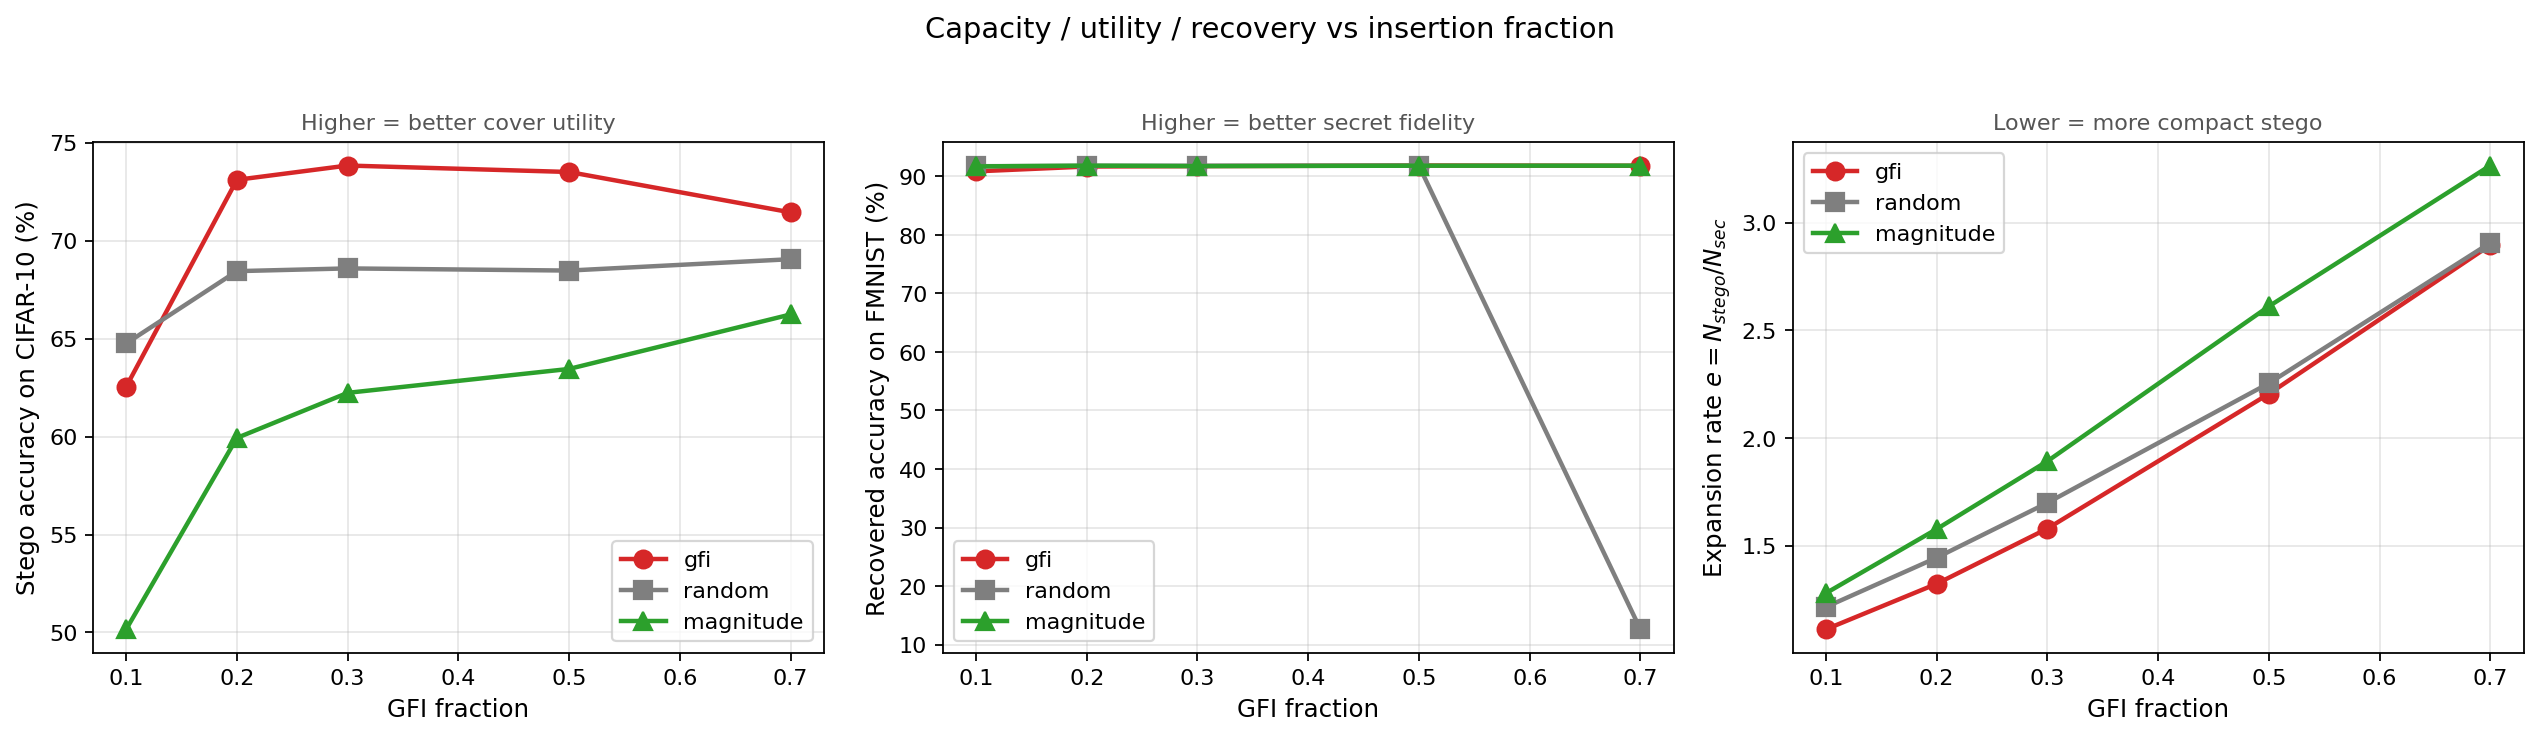


--- sweep_tradeoff.png ---


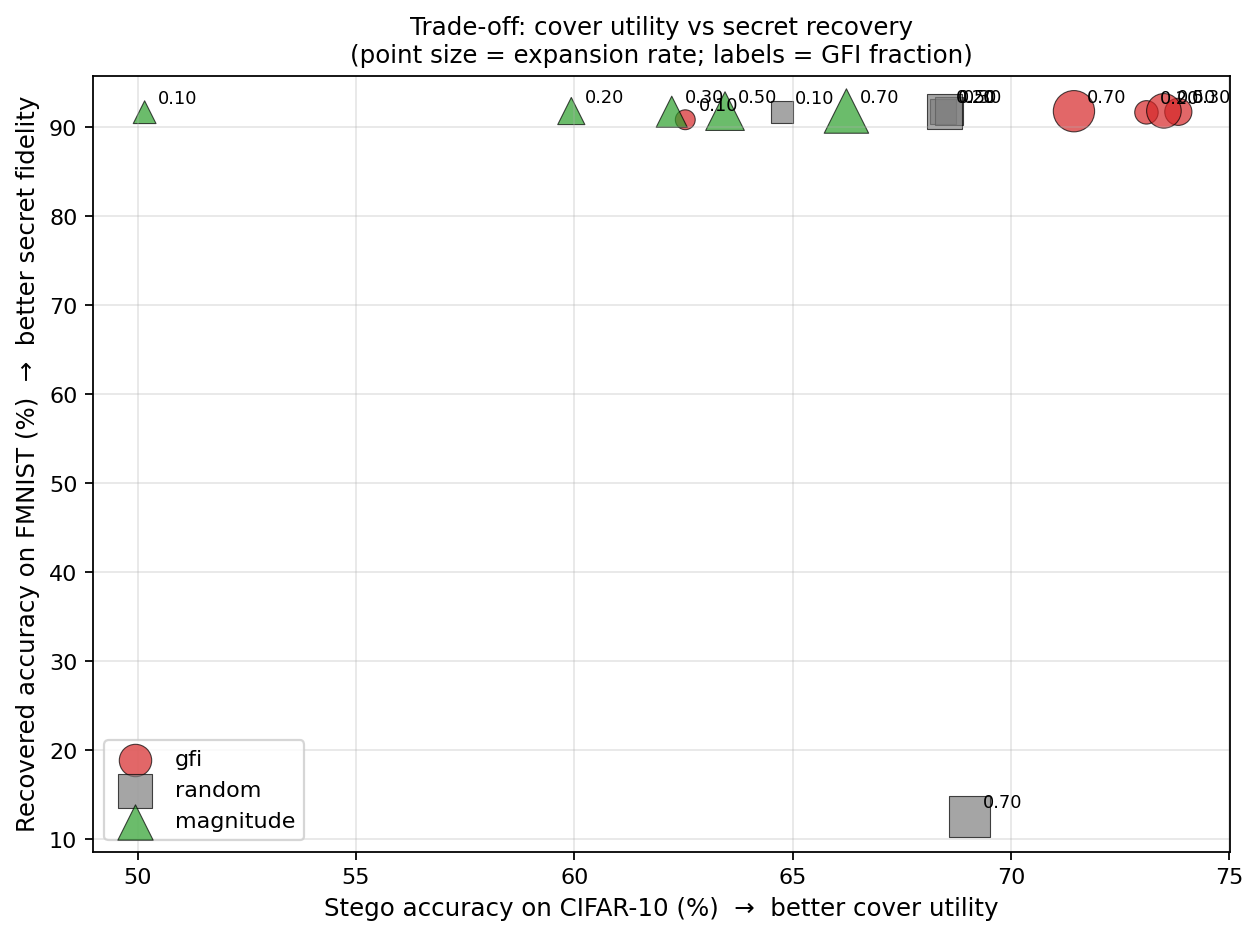


--- sweep_capacity.png ---


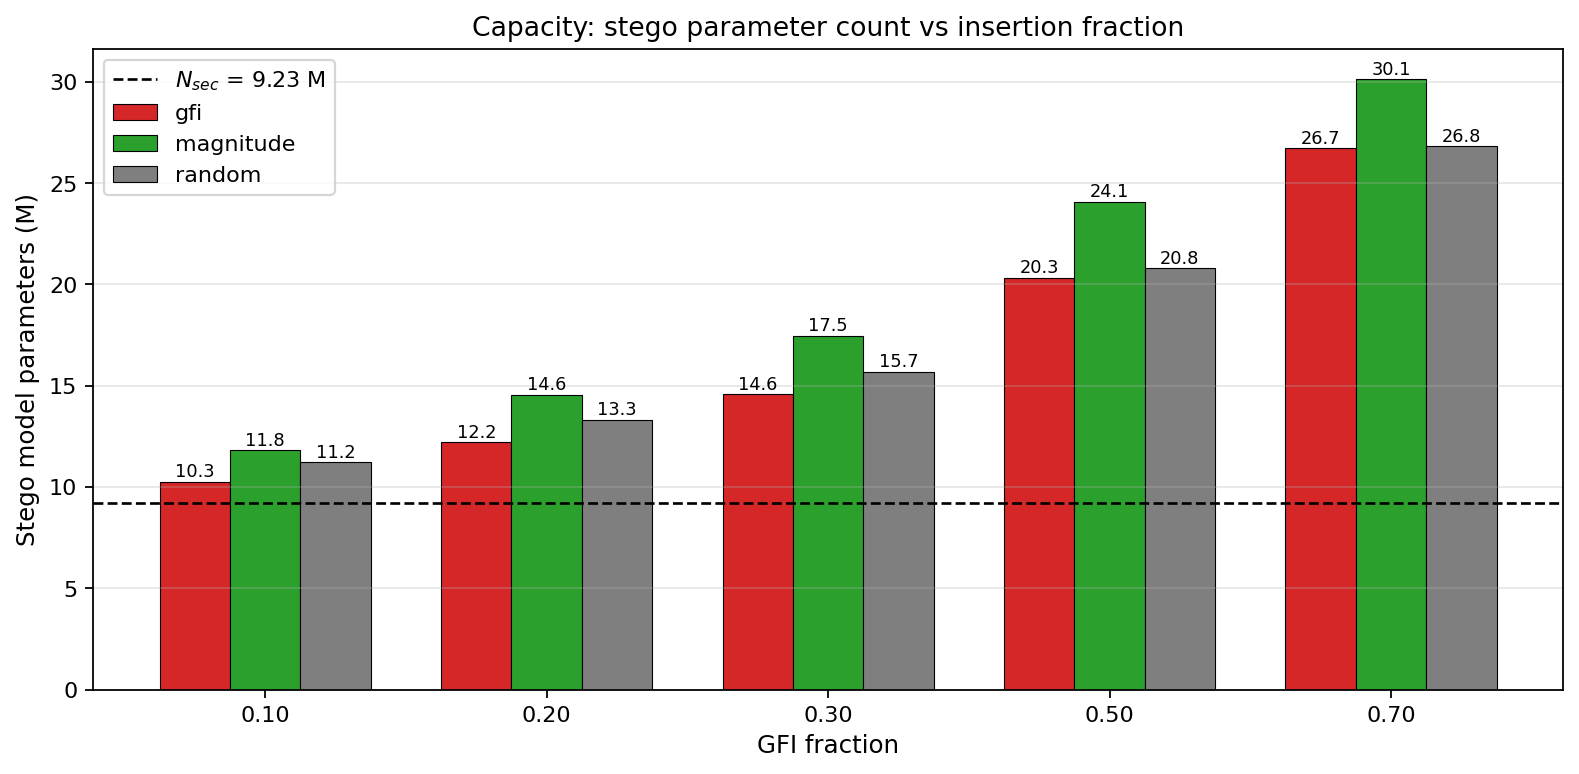

In [18]:
# =============================================================================
# CELL: PLOTS FROM SWEEP METRICS
#
# Run this AFTER the sweep cell has populated the JSONL file. Reads the file,
# writes three figures to Drive, and displays them inline.
# =============================================================================

import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

METRICS_PATH = Path("/content/drive/My Drive/CS682-Project/sweep_metrics.jsonl")
OUT_DIR      = Path("/content/drive/My Drive/CS682-Project/figures_sweep")
SEED         = 0  # plot only rows with this seed

OUT_DIR.mkdir(parents=True, exist_ok=True)

STRATEGY_COLORS  = {"gfi": "#d62728", "random": "#7f7f7f", "magnitude": "#2ca02c"}
STRATEGY_MARKERS = {"gfi": "o",       "random": "s",       "magnitude": "^"}

# ----- Load metrics ---------------------------------------------------------

rows = []
with open(METRICS_PATH) as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))
rows = [r for r in rows if r["seed"] == SEED]
print(f"Loaded {len(rows)} rows for seed={SEED} from {METRICS_PATH}")

assert rows, "No rows to plot — run the sweep cell first."

groups = {}
for r in rows:
    groups.setdefault(r["strategy"], []).append(r)
for s in groups:
    groups[s].sort(key=lambda r: r["gfi_fraction"])

plt.rcParams.update({
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10,
})

# ----- Figure 1: Pareto (3 panels) ------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
specs = [
    ("acc_stego",      "Stego accuracy on CIFAR-10 (%)",         100.0, "Higher = better cover utility"),
    ("acc_recovered",  "Recovered accuracy on FMNIST (%)",       100.0, "Higher = better secret fidelity"),
    ("expansion_rate", r"Expansion rate $e = N_{stego}/N_{sec}$", 1.0,  "Lower = more compact stego"),
]
for ax, (key, ylabel, scale, subtitle) in zip(axes, specs):
    for strat, runs in groups.items():
        xs = [r["gfi_fraction"] for r in runs]
        ys = [r[key] * scale for r in runs]
        ax.plot(xs, ys, marker=STRATEGY_MARKERS.get(strat, "o"),
                color=STRATEGY_COLORS.get(strat, "#000"),
                linewidth=2, markersize=8, label=strat)
    ax.set_xlabel("GFI fraction")
    ax.set_ylabel(ylabel)
    ax.set_title(subtitle, fontsize=10, color="#555")
    ax.grid(alpha=0.3); ax.legend()
fig.suptitle("Capacity / utility / recovery vs insertion fraction", fontsize=13, y=1.02)
fig.tight_layout()
pareto_path = OUT_DIR / "sweep_pareto.png"
fig.savefig(pareto_path, dpi=160, bbox_inches="tight")
plt.close(fig)
print(f"Saved {pareto_path}")

# ----- Figure 2: Trade-off scatter ------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))
all_e = [r["expansion_rate"] for r in rows]
e_min, e_max = min(all_e), max(all_e)
size = lambda e: 200 if e_max == e_min else 80 + 320 * (e - e_min) / (e_max - e_min)

for strat, runs in groups.items():
    xs = [r["acc_stego"]     * 100 for r in runs]
    ys = [r["acc_recovered"] * 100 for r in runs]
    ss = [size(r["expansion_rate"]) for r in runs]
    ax.scatter(xs, ys, s=ss, alpha=0.7,
               color=STRATEGY_COLORS.get(strat, "#000"),
               marker=STRATEGY_MARKERS.get(strat, "o"),
               edgecolor="black", linewidth=0.5, label=strat)
    for r, x, y in zip(runs, xs, ys):
        ax.annotate(f"{r['gfi_fraction']:.2f}", (x, y),
                    xytext=(6, 4), textcoords="offset points", fontsize=8)

ax.set_xlabel("Stego accuracy on CIFAR-10 (%)  →  better cover utility")
ax.set_ylabel("Recovered accuracy on FMNIST (%)  →  better secret fidelity")
ax.set_title("Trade-off: cover utility vs secret recovery\n"
             "(point size = expansion rate; labels = GFI fraction)",
             fontsize=11)
ax.grid(alpha=0.3); ax.legend(loc="lower left")
fig.tight_layout()
tradeoff_path = OUT_DIR / "sweep_tradeoff.png"
fig.savefig(tradeoff_path, dpi=160, bbox_inches="tight")
plt.close(fig)
print(f"Saved {tradeoff_path}")

# ----- Figure 3: Capacity bars ----------------------------------------------

n_sec = rows[0]["n_sec"]
fractions = sorted({r["gfi_fraction"] for r in rows})
x = np.arange(len(fractions))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
for i, strat in enumerate(sorted(groups.keys())):
    by_f = {r["gfi_fraction"]: r for r in groups[strat]}
    heights = [by_f[f]["n_stego"] / 1e6 if f in by_f else 0 for f in fractions]
    offset = (i - (len(groups) - 1) / 2) * width
    bars = ax.bar(x + offset, heights, width,
                  color=STRATEGY_COLORS.get(strat, "#000"),
                  edgecolor="black", linewidth=0.5, label=strat)
    for bar, h in zip(bars, heights):
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.05,
                    f"{h:.1f}", ha="center", va="bottom", fontsize=8)

ax.axhline(n_sec / 1e6, color="black", linestyle="--", linewidth=1.2,
           label=f"$N_{{sec}}$ = {n_sec/1e6:.2f} M")
ax.set_xticks(x)
ax.set_xticklabels([f"{f:.2f}" for f in fractions])
ax.set_xlabel("GFI fraction")
ax.set_ylabel("Stego model parameters (M)")
ax.set_title("Capacity: stego parameter count vs insertion fraction")
ax.legend(); ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
capacity_path = OUT_DIR / "sweep_capacity.png"
fig.savefig(capacity_path, dpi=160, bbox_inches="tight")
plt.close(fig)
print(f"Saved {capacity_path}")

# ----- Display them inline --------------------------------------------------

for path in (pareto_path, tradeoff_path, capacity_path):
    print(f"\n--- {path.name} ---")
    display(Image(str(path)))